# IY028 — Embedding Space Visualisation with PHATE

PHATE (Potential of Heat-diffusion for Affinity-based Trajectory Embedding) is a nonlinear dimensionality reduction method that preserves both local and global structure via a diffusion operator. It often reveals continuous manifold structure that t-SNE fragements into disconnected islands.

This notebook applies PHATE to four representations on both the **old** (6-class glucose × TF) and **new** (12-class TF screening) dual-channel experimental datasets from `EXP-25-IY008`:

1. Raw dual-channel time-series features (pure SVM baseline).
2. catch22 features extracted separately from mCherry and GFP, then concatenated.
3. Frozen SimCLR backbone embeddings from the best IY024 dual-channel checkpoint.
4. SimCLR + SVM decision-score vectors (RBF SVM fitted on SimCLR embeddings).

Output figures are saved as `IY028_phate_<old|new>_<representation>.png`.

In [1]:
import sys
from pathlib import Path

_src_root = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src").exists() and (candidate / "experiments").exists()
)
sys.path.insert(0, str((_src_root / "src").resolve()))
from utils.paths import find_project_root

import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phate
import pycatch22
import seaborn as sns
import torch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "experiments"
IY028_DIR = EXP_DIR / "EXP-26-IY028"
SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR.resolve()))
from models.ssl_transformer import SSL_Transformer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
META_COLS = ["id", "group", "experiment"]

# Best dual-channel SimCLR checkpoint (IY024 cross-view).
BEST_SIMCLR_CKPT = EXP_DIR / "EXP-26-IY024" / "IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Project root : {PROJECT_ROOT}")
print(f"Checkpoint   : {BEST_SIMCLR_CKPT.exists()} -> {BEST_SIMCLR_CKPT.name}")
print(f"Device       : {DEVICE}")
print(f"PHATE version: {phate.__version__}")

Project root : /home/ianyang/stochastic_simulations
Checkpoint   : True -> IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth
Device       : cuda
PHATE version: 2.0.0


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Shared Utility Functions

Preprocessing, feature extraction, SimCLR encoding, and PHATE reduction are factored into reusable helpers used by both the OLD and NEW dataset sections.

In [2]:
from utils.processing.imputation import fill_nans
from utils.processing.balancing import balance_by_label
from utils.embeddings import parse_arch_from_name, load_simclr_model, encode_channel

# ---------------------------------------------------------------------------
# Feature extraction
# ---------------------------------------------------------------------------

def extract_catch22_features(X, prefix):
    """Return a catch22 feature DataFrame for an array of cell traces."""
    records, feature_names = [], None
    for trace in tqdm(X, desc=f"catch22 {prefix}"):
        result = pycatch22.catch22_all(trace.tolist())
        if feature_names is None:
            feature_names = [f"{prefix}_{n}" for n in result["names"]]
        records.append(result["values"])
    features = pd.DataFrame(records, columns=feature_names).replace([np.inf, -np.inf], np.nan)
    return features.fillna(features.median(numeric_only=True)).fillna(0.0)


# ---------------------------------------------------------------------------
# PHATE reduction
# ---------------------------------------------------------------------------

def run_phate(X, n_components=2, knn=5, decay=40, knn_dist="euclidean", random_state=42, n_jobs=1):
    """
    Run PHATE on a scaled feature matrix and return 2-D coordinates.

    Parameters
    ----------
    X : ndarray, shape (n_cells, n_features)
        Pre-scaled input matrix.
    knn : int
        Number of nearest neighbours for the kernel (default 5, the PHATE default).
        Increase if PHATE warns about a disconnected graph.
    decay : int
        Alpha-decay parameter controlling how fast the kernel decays (default 40).
    knn_dist : str
        Distance metric for nearest-neighbour graph (default "euclidean").
    """
    phate_op = phate.PHATE(
        n_components=n_components,
        knn=knn,
        decay=decay,
        knn_dist=knn_dist,
        random_state=random_state,
        n_jobs=n_jobs,
        verbose=False,
    )
    return phate_op.fit_transform(X)


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_phate_panel(
    coords_dict,
    metadata,
    hue_col,
    style_col,
    title,
    out_path,
    palette="colorblind",
):
    """
    Plot a 1×N grid of PHATE scatter panels — one column per representation.

    Parameters
    ----------
    coords_dict : dict[str, ndarray]
        Mapping from representation name to (n_cells, 2) PHATE coordinates.
    metadata : DataFrame
        Cell metadata aligned row-by-row with the coordinates.
    hue_col : str
        Metadata column used for point colour (class label).
    style_col : str or None
        Metadata column used for point marker style (e.g. TF or experiment).
    """
    representations = list(coords_dict)
    n_cols = len(representations)
    fig, axes = plt.subplots(
        1, n_cols,
        figsize=(5 * n_cols, 5),
        constrained_layout=True,
        squeeze=False,
    )

    for col, rep in enumerate(representations):
        ax = axes[0, col]
        df = metadata.copy()
        df["PHATE 1"] = coords_dict[rep][:, 0]
        df["PHATE 2"] = coords_dict[rep][:, 1]

        scatter_kws = dict(
            data=df, x="PHATE 1", y="PHATE 2",
            hue=hue_col,
            s=35, alpha=0.80, linewidth=0.2, edgecolor="black",
            palette=palette, ax=ax,
        )
        if style_col:
            scatter_kws["style"] = style_col

        sns.scatterplot(**scatter_kws)
        ax.set_title(rep, fontsize=14)
        ax.set_xlabel("PHATE 1 / a.u.", fontsize=12)
        ax.set_ylabel("PHATE 2 / a.u.", fontsize=12)
        ax.legend_.remove()

    # Single shared legend outside the axes.
    handles, lbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, lbls, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    fig.suptitle(title, fontsize=14)

    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()


print("Utility functions defined.")

Utility functions defined.


---
## Part 1 — OLD Dataset (6-class glucose × TF)

Data from `EXP-25-IY008/4_transformed_exp_time_series`: six classes formed by Nrg1/Rtg1 × 2% / 0.1% / 0.01% glucose, matched to the original IY028 SVM notebooks.

In [3]:
OLD_DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series"

OLD_FILE_PAIRS = [
    (
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series",
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series",
        0, "2% glucose", "Nrg1",
    ),
    (
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series",
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series",
        1, "0.1% glucose", "Nrg1",
    ),
    (
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series",
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series",
        2, "0.01% glucose", "Nrg1",
    ),
    (
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series",
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series",
        3, "2% glucose", "Rtg1",
    ),
    (
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series",
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series",
        4, "0.1% glucose", "Rtg1",
    ),
    (
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series",
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series",
        5, "0.01% glucose", "Rtg1",
    ),
]

OLD_LABEL_NAMES = {
    0: "Nrg1 @ 2% glucose",
    1: "Nrg1 @ 0.1% glucose",
    2: "Nrg1 @ 0.01% glucose",
    3: "Rtg1 @ 2% glucose",
    4: "Rtg1 @ 0.1% glucose",
    5: "Rtg1 @ 0.01% glucose",
}


def load_old_dataset(data_dir):
    """Load the six glucose×TF paired mCherry/GFP datasets."""
    m_arrays, g_arrays, rows = [], [], []
    for mcherry_stem, gfp_stem, label, glucose, tf_name in OLD_FILE_PAIRS:
        df_m = pd.read_csv(data_dir / f"{mcherry_stem}.csv")
        df_g = pd.read_csv(data_dir / f"{gfp_stem}.csv")
        time_cols_m = [c for c in df_m.columns if c not in META_COLS]
        time_cols_g = [c for c in df_g.columns if c not in META_COLS]
        common_ids = sorted(set(df_m["id"]) & set(df_g["id"]))
        df_m = df_m[df_m["id"].isin(common_ids)].set_index("id").loc[common_ids]
        df_g = df_g[df_g["id"].isin(common_ids)].set_index("id").loc[common_ids]
        m_arrays.append(df_m[time_cols_m].to_numpy(float))
        g_arrays.append(df_g[time_cols_g].to_numpy(float))
        for cell_id in common_ids:
            rows.append({
                "cell_id": cell_id,
                "label": label,
                "class_name": OLD_LABEL_NAMES[label],
                "glucose": glucose,
                "tf": tf_name,
            })
        print(f"{OLD_LABEL_NAMES[label]:24s}: {len(common_ids):4d} paired cells")

    min_tp_m = min(a.shape[1] for a in m_arrays)
    min_tp_g = min(a.shape[1] for a in g_arrays)
    X_m = np.vstack([a[:, :min_tp_m] for a in m_arrays])
    X_g = np.vstack([a[:, :min_tp_g] for a in g_arrays])
    return X_m, X_g, pd.DataFrame(rows)


X_m_old_raw, X_g_old_raw, meta_old_raw = load_old_dataset(OLD_DATA_DIR)
print(f"\nmCherry: {X_m_old_raw.shape} | GFP: {X_g_old_raw.shape}")

Nrg1 @ 2% glucose       :   84 paired cells
Nrg1 @ 0.1% glucose     :  231 paired cells
Nrg1 @ 0.01% glucose    :  231 paired cells
Rtg1 @ 2% glucose       :   78 paired cells
Rtg1 @ 0.1% glucose     :  200 paired cells
Rtg1 @ 0.01% glucose    :  275 paired cells

mCherry: (1099, 89) | GFP: (1099, 80)


In [4]:
# Impute, balance, and z-score the OLD dataset.
X_m_old = fill_nans(X_m_old_raw)
X_g_old = fill_nans(X_g_old_raw)
X_m_old_bal, X_g_old_bal, meta_old = balance_by_label(X_m_old, X_g_old, meta_old_raw, RANDOM_STATE)
X_m_old_norm = StandardScaler().fit_transform(X_m_old_bal)
X_g_old_norm = StandardScaler().fit_transform(X_g_old_bal)

print(f"Balanced mCherry: {X_m_old_bal.shape} | GFP: {X_g_old_bal.shape}")
display(meta_old["class_name"].value_counts().sort_index().rename_axis("class_name").reset_index(name="n"))

Balanced mCherry: (468, 89) | GFP: (468, 80)


,class_name,n
0,Nrg1 @ 0.01% glucose,78
1,Nrg1 @ 0.1% glucose,78
2,Nrg1 @ 2% glucose,78
3,Rtg1 @ 0.01% glucose,78
4,Rtg1 @ 0.1% glucose,78
5,Rtg1 @ 2% glucose,78


### Extract OLD Representations

In [5]:
# 0. Raw time-series features (concatenated channels, scaled).
old_raw_features = StandardScaler().fit_transform(
    np.concatenate([X_m_old_norm, X_g_old_norm], axis=1)
)
print(f"[OLD] Raw features : {old_raw_features.shape}")

# 1. catch22 features.
c22_m_old = extract_catch22_features(X_m_old_bal, "mCherry")
c22_g_old = extract_catch22_features(X_g_old_bal, "GFP")
old_catch22 = StandardScaler().fit_transform(pd.concat([c22_m_old, c22_g_old], axis=1))
print(f"[OLD] catch22      : {old_catch22.shape}")

# 2. SimCLR embeddings (frozen IY024 backbone).
simclr_model = load_simclr_model(BEST_SIMCLR_CKPT, DEVICE)
Z_m_old = encode_channel(simclr_model, X_m_old_norm, DEVICE)
Z_g_old = encode_channel(simclr_model, X_g_old_norm, DEVICE)
old_simclr = StandardScaler().fit_transform(np.concatenate([Z_m_old, Z_g_old], axis=1))
print(f"[OLD] SimCLR       : {old_simclr.shape}")

# # 3. SimCLR + SVM decision scores.
# old_labels = meta_old["label"].to_numpy()
# svm_old = SVC(kernel="rbf", C=1.0, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE)
# svm_old.fit(old_simclr, old_labels)
# old_svm_scores_raw = svm_old.decision_function(old_simclr)
# if old_svm_scores_raw.ndim == 1:
#     old_svm_scores_raw = old_svm_scores_raw[:, None]
# old_svm_scores = StandardScaler().fit_transform(old_svm_scores_raw)
# print(f"[OLD] SVM scores   : {old_svm_scores.shape}")

[OLD] Raw features : (468, 169)


catch22 mCherry:   0%|          | 0/468 [00:00<?, ?it/s]

catch22 mCherry:  60%|█████▉    | 280/468 [00:00<00:00, 2790.00it/s]

catch22 mCherry: 100%|██████████| 468/468 [00:00<00:00, 2801.03it/s]

catch22 GFP:   0%|          | 0/468 [00:00<?, ?it/s]

...

catch22 GFP: 100%|██████████| 468/468 [00:00<00:00, 3073.11it/s]

[OLD] catch22      : (468, 44)


SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

[OLD] SimCLR       : (468, 32)


### PHATE — OLD Dataset

PHATE is run with its defaults (`knn=5`, `decay=40`). If the graph becomes disconnected at knn=5, PHATE will warn and you should increase knn. Results are overlaid with the six glucose × TF class labels.

In [6]:
# Run PHATE on all four OLD representations.
# knn is capped at n_samples - 1 to guard against tiny balanced classes.
n_old = old_raw_features.shape[0]
knn_old = min(5, n_old - 1)

print(f"Running PHATE on OLD dataset ({n_old} cells, knn={knn_old})...")
old_phate_coords = {
    "Raw SVM features":    run_phate(old_raw_features, knn=knn_old, random_state=RANDOM_STATE),
    "catch22":             run_phate(old_catch22,       knn=knn_old, random_state=RANDOM_STATE),
    "SimCLR":              run_phate(old_simclr,        knn=knn_old, random_state=RANDOM_STATE),
    # "SimCLR + SVM scores": run_phate(old_svm_scores,   knn=knn_old, random_state=RANDOM_STATE),
}
print("Done.")

Running PHATE on OLD dataset (468 cells, knn=5)...


    SGD-MDS may not have converged: stress changed by -1.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.


    SGD-MDS may not have converged: stress changed by -15.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


    SGD-MDS may not have converged: stress changed by 1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.


Done.


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_phate_old.png


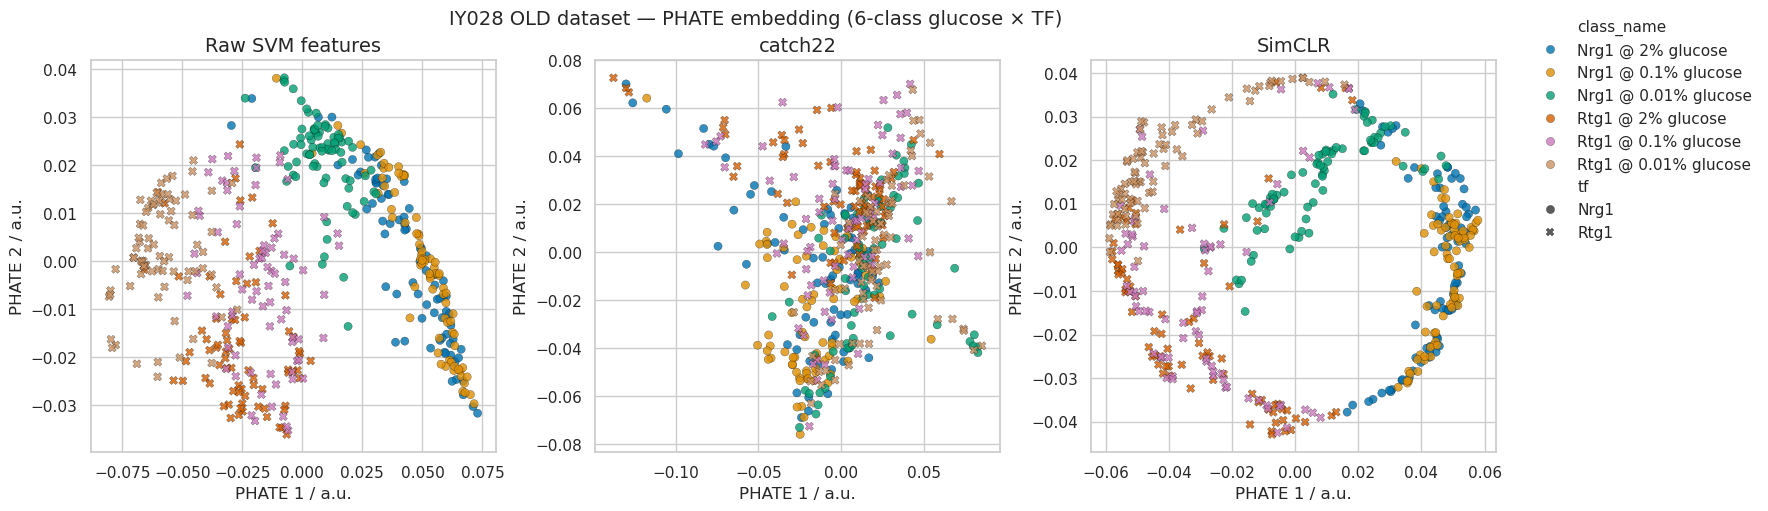

In [7]:
plot_phate_panel(
    coords_dict=old_phate_coords,
    metadata=meta_old,
    hue_col="class_name",
    style_col="tf",
    title="IY028 OLD dataset — PHATE embedding (6-class glucose × TF)",
    out_path=IY028_DIR / "IY028_phate_old.png",
)

---
## Part 2 — NEW Dataset (12-class TF screening)

Data from `EXP-25-IY008/4_transformed_exp_time_series_NEW`: paired mCherry/GFP files discovered automatically. TF classes with at least 50 paired cells are kept; the top 12 by paired-cell count are selected.

In [8]:
from dataloaders.experimental_pairs import discover_paired_files, normalise_tf_name
NEW_DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series_NEW"
MIN_CELLS_PER_CLASS = 50
MAX_CLASSES = 12


def load_new_dataset(pair_table, selected_classes):
    """Load all paired cells for the selected TF classes."""
    m_arrays, g_arrays, meta_rows = [], [], []
    for _, row in pair_table[pair_table["tf"].isin(selected_classes)].iterrows():
        df_m = pd.read_csv(row["mcherry_path"])
        df_g = pd.read_csv(row["gfp_path"])
        time_m = [c for c in df_m.columns if c not in META_COLS]
        time_g = [c for c in df_g.columns if c not in META_COLS]
        common_ids = sorted(set(df_m["id"]) & set(df_g["id"]))
        df_m = df_m[df_m["id"].isin(common_ids)].set_index("id").loc[common_ids]
        df_g = df_g[df_g["id"].isin(common_ids)].set_index("id").loc[common_ids]
        m_arrays.append(df_m[time_m].to_numpy(float))
        g_arrays.append(df_g[time_g].to_numpy(float))
        for cell_id in common_ids:
            meta_rows.append({
                "cell_id": cell_id,
                "class_name": row["tf"],
                "tf": row["tf"],
                "experiment": row["experiment"],
            })
    min_tp_m = min(a.shape[1] for a in m_arrays)
    min_tp_g = min(a.shape[1] for a in g_arrays)
    X_m = np.vstack([a[:, :min_tp_m] for a in m_arrays])
    X_g = np.vstack([a[:, :min_tp_g] for a in g_arrays])
    metadata = pd.DataFrame(meta_rows)
    class_to_label = {c: i for i, c in enumerate(selected_classes)}
    metadata["label"] = metadata["class_name"].map(class_to_label).astype(int)
    return X_m, X_g, metadata


# Discover and select the top TF classes.
pair_table = discover_paired_files(NEW_DATA_DIR)
class_counts = (
    pair_table.groupby("tf", as_index=False)["n_rows"]
    .sum().rename(columns={"n_rows": "paired_cells"})
    .sort_values("paired_cells", ascending=False)
)
selected_classes = (
    class_counts
    .loc[class_counts["paired_cells"] >= MIN_CELLS_PER_CLASS, "tf"]
    .head(MAX_CLASSES)
    .tolist()
)
print(f"Selected {len(selected_classes)} TF classes: {selected_classes}")

X_m_new_raw, X_g_new_raw, meta_new_raw = load_new_dataset(pair_table, selected_classes)
print(f"mCherry: {X_m_new_raw.shape} | GFP: {X_g_new_raw.shape}")

Selected 12 TF classes: ['OPI1', 'MSN2', 'YOX1', 'TEA1', 'ROX1', 'SOK2', 'CUP9', 'SPT15', 'CBF1', 'STB5', 'CIN5', 'RSC3']
mCherry: (1720, 18) | GFP: (1720, 18)


In [9]:
# Impute, balance, and z-score the NEW dataset.
X_m_new = fill_nans(X_m_new_raw)
X_g_new = fill_nans(X_g_new_raw)
X_m_new_bal, X_g_new_bal, meta_new = balance_by_label(X_m_new, X_g_new, meta_new_raw, RANDOM_STATE)
X_m_new_norm = StandardScaler().fit_transform(X_m_new_bal)
X_g_new_norm = StandardScaler().fit_transform(X_g_new_bal)

print(f"Balanced mCherry: {X_m_new_bal.shape} | GFP: {X_g_new_bal.shape}")
display(meta_new["class_name"].value_counts().sort_index().rename_axis("class_name").reset_index(name="n"))

Balanced mCherry: (1272, 18) | GFP: (1272, 18)


,class_name,n
0,CBF1,106
1,CIN5,106
2,CUP9,106
3,MSN2,106
4,OPI1,106
5,ROX1,106
6,RSC3,106
7,SOK2,106
8,SPT15,106
9,STB5,106


### Extract NEW Representations

In [10]:
# 0. Raw time-series features.
new_raw_features = StandardScaler().fit_transform(
    np.concatenate([X_m_new_norm, X_g_new_norm], axis=1)
)
print(f"[NEW] Raw features : {new_raw_features.shape}")

# 1. catch22.
c22_m_new = extract_catch22_features(X_m_new_bal, "mCherry")
c22_g_new = extract_catch22_features(X_g_new_bal, "GFP")
new_catch22 = StandardScaler().fit_transform(pd.concat([c22_m_new, c22_g_new], axis=1))
print(f"[NEW] catch22      : {new_catch22.shape}")

# 2. SimCLR (reuse the already-loaded frozen model).
Z_m_new = encode_channel(simclr_model, X_m_new_norm, DEVICE)
Z_g_new = encode_channel(simclr_model, X_g_new_norm, DEVICE)
new_simclr = StandardScaler().fit_transform(np.concatenate([Z_m_new, Z_g_new], axis=1))
print(f"[NEW] SimCLR       : {new_simclr.shape}")

# # 3. SimCLR + SVM decision scores.
# new_labels = meta_new["label"].to_numpy()
# svm_new = SVC(kernel="rbf", C=1.0, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE)
# svm_new.fit(new_simclr, new_labels)
# new_svm_scores_raw = svm_new.decision_function(new_simclr)
# if new_svm_scores_raw.ndim == 1:
#     new_svm_scores_raw = new_svm_scores_raw[:, None]
# new_svm_scores = StandardScaler().fit_transform(new_svm_scores_raw)
# print(f"[NEW] SVM scores   : {new_svm_scores.shape}")

[NEW] Raw features : (1272, 36)


catch22 mCherry:   0%|          | 0/1272 [00:00<?, ?it/s]

catch22 mCherry:  95%|█████████▌| 1210/1272 [00:00<00:00, 12094.65it/s]

catch22 mCherry: 100%|██████████| 1272/1272 [00:00<00:00, 12067.05it/s]

catch22 GFP:   0%|          | 0/1272 [00:00<?, ?it/s]

...

catch22 GFP: 100%|██████████| 1272/1272 [00:00<00:00, 12139.31it/s]

[NEW] catch22      : (1272, 44)


SimCLR encode:   0%|          | 0/5 [00:00<?, ?it/s]

SimCLR encode:   0%|          | 0/5 [00:00<?, ?it/s]

[NEW] SimCLR       : (1272, 32)


### PHATE — NEW Dataset

PHATE is run with its defaults (`knn=5`, `decay=40`). With 1 200+ cells and 12 classes the manifold should reveal whether the TF classes form distinct continua or isolated clusters in each representation.

In [11]:
n_new = new_raw_features.shape[0]
knn_new = min(5, n_new - 1)

print(f"Running PHATE on NEW dataset ({n_new} cells, knn={knn_new})...")
new_phate_coords = {
    "Raw SVM features":    run_phate(new_raw_features, knn=knn_new, random_state=RANDOM_STATE),
    "catch22":             run_phate(new_catch22,       knn=knn_new, random_state=RANDOM_STATE),
    "SimCLR":              run_phate(new_simclr,        knn=knn_new, random_state=RANDOM_STATE),
    # "SimCLR + SVM scores": run_phate(new_svm_scores,   knn=knn_new, random_state=RANDOM_STATE),
}
print("Done.")

Running PHATE on NEW dataset (1272 cells, knn=5)...


    SGD-MDS may not have converged: stress changed by -12.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.


Done.


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_phate_new.png


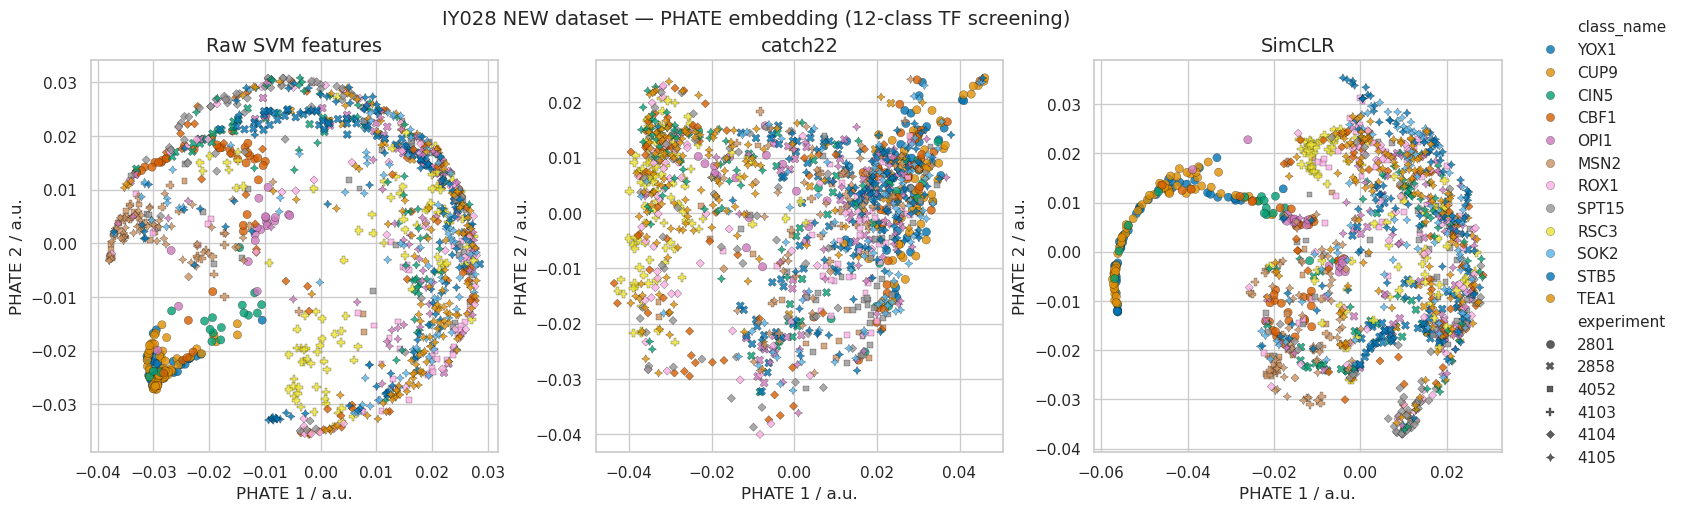

In [12]:
plot_phate_panel(
    coords_dict=new_phate_coords,
    metadata=meta_new,
    hue_col="class_name",
    style_col="experiment",
    title="IY028 NEW dataset — PHATE embedding (12-class TF screening)",
    out_path=IY028_DIR / "IY028_phate_new.png",
)

---
## Side-by-side: SimCLR PHATE (OLD vs NEW)

Placing the SimCLR PHATE embeddings for both datasets next to each other allows direct visual comparison of how well the frozen IY024 backbone separates classes in each setting.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_phate_simclr_comparison.png


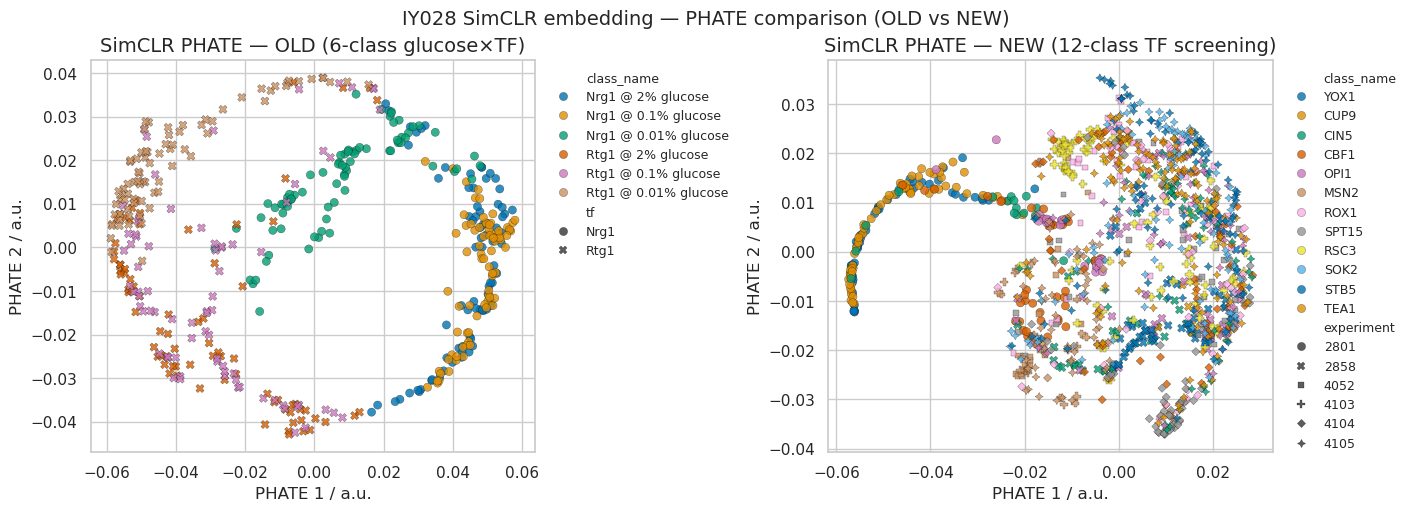

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (coords, meta, hue_col, style_col, subtitle) in zip(axes, [
    (old_phate_coords["SimCLR"], meta_old, "class_name", "tf",         "OLD (6-class glucose×TF)"),
    (new_phate_coords["SimCLR"], meta_new, "class_name", "experiment", "NEW (12-class TF screening)"),
]):
    df = meta.copy()
    df["PHATE 1"] = coords[:, 0]
    df["PHATE 2"] = coords[:, 1]
    sns.scatterplot(
        data=df, x="PHATE 1", y="PHATE 2",
        hue=hue_col, style=style_col,
        s=35, alpha=0.80, linewidth=0.2, edgecolor="black",
        palette="colorblind", ax=ax,
    )
    ax.set_title(f"SimCLR PHATE — {subtitle}", fontsize=14)
    ax.set_xlabel("PHATE 1 / a.u.", fontsize=12)
    ax.set_ylabel("PHATE 2 / a.u.", fontsize=12)
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend_.remove()
    ax.legend(handles, lbls, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=9)

fig.suptitle("IY028 SimCLR embedding — PHATE comparison (OLD vs NEW)", fontsize=14)
out_path = IY028_DIR / "IY028_phate_simclr_comparison.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()